In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import time
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [2]:
random_seed = 42
lr = 0.001
batch_size = 64
epochs = 10
num_classes = 10

In [3]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

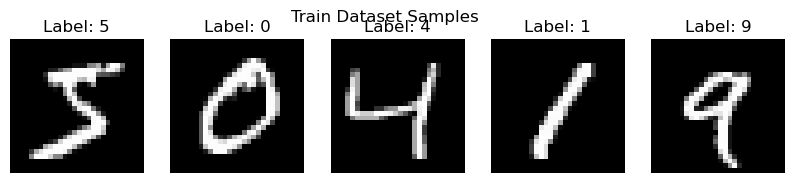

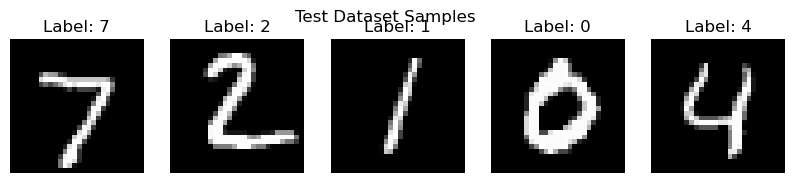

Train dataset size: 60000
Train dataset classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Size of each data sample in train_dataset: torch.Size([1, 28, 28])
Type of image: <class 'torch.Tensor'>, Type of label: <class 'int'>


In [4]:
def show_images(dataset, title, num_images=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_images):
        image, label = dataset[i]
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        plt.title(f'Label: {label}')
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

show_images(train_dataset, 'Train Dataset Samples')
show_images(test_dataset, 'Test Dataset Samples')

print(f'Train dataset size: {len(train_dataset)}')
print(f'Train dataset classes: {train_dataset.classes}')
# Each item in the dataset is a tuple: (image, label)
# image: torch.Tensor of shape [1, 28, 28] (grayscale MNIST image)
# label: int (digit class 0-9)
print(f'Size of each data sample in train_dataset: {train_dataset[0][0].shape}')
print(f'Type of image: {type(train_dataset[0][0])}, Type of label: {type(train_dataset[0][1])}')

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
class VAEBottleneck(nn.Module):
    def __init__(self, in_dim, latent_dim):
        super().__init__()
        self.fc_mu = nn.Linear(in_dim, latent_dim)
        self.fc_logvar = nn.Linear(in_dim, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, in_dim)

    def reparameterize(self, u, logvar):
        std = torch.exp(0.5 * logvar)
        e = torch.randn_like(std)
        return u + std * e

    def forward(self, x):
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.fc_decode(z)
        return x_recon, mu, logvar

    
class VariationalAutoEncoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()
        self.latent_dim = latent_dim

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),  # 1x28x28 -> 16x28x28
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x28x28 -> 16x14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1), # 16x14x14 -> 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x14x14 -> 32x7x7

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 32x7x7 -> 64x7x7
            nn.BatchNorm2d(64),
            nn.ReLU()
        )

        self.flatten = nn.Flatten()
        self.bottleneck = VAEBottleneck(64 * 7 * 7, latent_dim)
        self.unflatten = nn.Unflatten(1, (64, 7, 7))

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 64x7x7 -> 32x14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2),  # 32x14x14 -> 16x28x28
            nn.BatchNorm2d(16),
            nn.ReLU(),

            nn.Conv2d(16, 1, kernel_size=3, padding=1),           # 16x28x28 -> 1x28x28
            nn.Sigmoid()                                          # Final output
        )

    def forward(self, x):
        x = self.encoder(x)
        x_flat = self.flatten(x)
        z_flat, mu, logvar = self.bottleneck(x_flat)
        x_unflat = self.unflatten(z_flat)
        out = self.decoder(x_unflat)
        return out, mu, logvar

    def get_latents(self, x):
        x = self.encoder(x)
        x_flat = self.flatten(x)
        z_flat, mu, logvar = self.bottleneck(x_flat)
        return z_flat

In [7]:
model = VariationalAutoEncoder().to(device)
print(model)

VariationalAutoEncoder(
  (fc_mu): Linear(in_features=3136, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=32, bias=True)
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (bottleneck): VAEBottleneck(
    (fc_mu): Linear(in_feature

In [8]:
from IPython.display import clear_output

def plot_losses(training_losses, test_losses):
    clear_output(wait=True)
    plt.figure(figsize=(8, 5))
    plt.plot(training_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Losses')
    plt.legend()
    plt.grid(True)
    plt.show()



In [9]:
def vae_loss_fn(recon_x, x, mu, logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')
    kl_div = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl_div

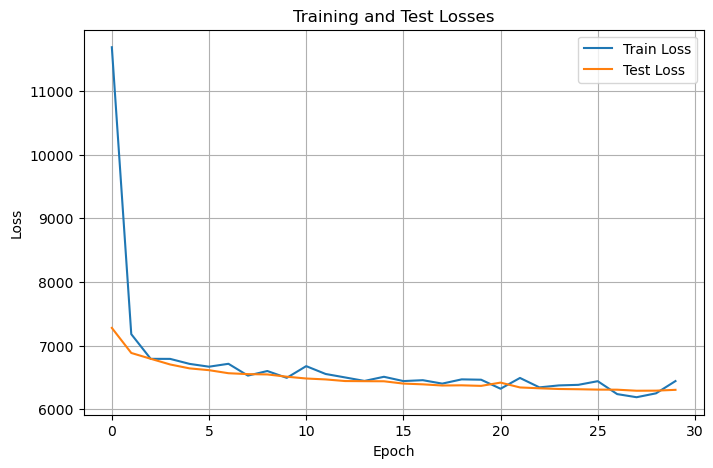

In [10]:
torch.manual_seed(random_seed)

num_epochs = 30
optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()

test_losses = []
training_losses = []

for epoch in range(num_epochs):
    model.train()
    batch_losses = []
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()

        output, mu, logvar = model(data)
        loss = vae_loss_fn(output, data, mu, logvar)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            batch_losses.append(loss.item())
            print(f'Epoch [{epoch+1}/{num_epochs}], Batch [{batch_idx+1}/{len(train_loader)}], Loss: {loss.item():.4f}')
    avg_loss = np.mean(batch_losses)
    print(f'Epoch [{epoch+1}/{num_epochs}] Average Loss: {avg_loss:.4f}')
    training_losses.append(avg_loss)

    # Evaluate test loss
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            output, mu, logvar = model(data)
            loss = vae_loss_fn(output, data, mu, logvar)
            test_loss += loss.item() * data.size(0)
    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)
    print(f'Epoch [{epoch+1}/{num_epochs}] Test Loss: {test_loss:.4f}')

    plot_losses(training_losses, test_losses)

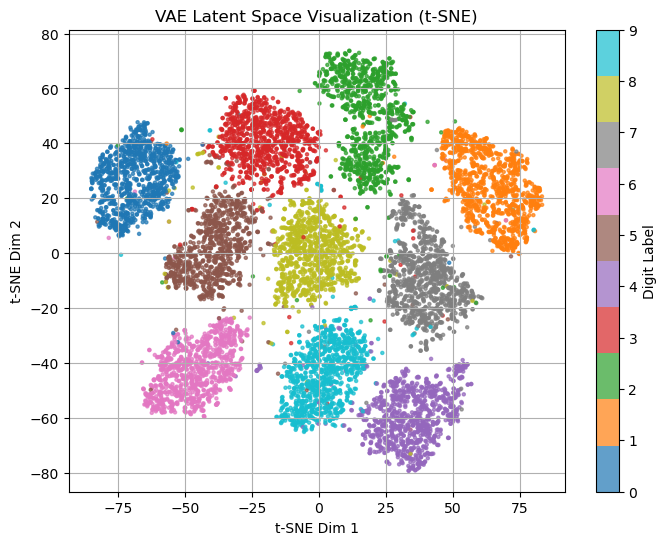

In [11]:
from sklearn.manifold import TSNE

# Collect latent vectors and labels from test set
model.eval()
latents = []
labels = []
with torch.no_grad():
    for data, target in test_loader:
        data = data.to(device)
        # Pass through encoder and bottleneck only
        encoded = model.encoder(data)
        encoded_flat = model.flatten(encoded)
        
        mu = model.bottleneck.fc_mu(encoded_flat)
        logvar = model.bottleneck.fc_logvar(encoded_flat)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        latent = mu + std * eps

        latents.append(mu.cpu().numpy())
        labels.append(target.numpy())
latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

# Run t-SNE
tsne = TSNE(n_components=2, random_state=random_seed)
latents_2d = tsne.fit_transform(latents)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap='tab10', s=5, alpha=0.7)
plt.colorbar(scatter, ticks=range(num_classes), label='Digit Label')
plt.title('VAE Latent Space Visualization (t-SNE)')
plt.xlabel('t-SNE Dim 1')
plt.ylabel('t-SNE Dim 2')
plt.grid(True)
plt.show()

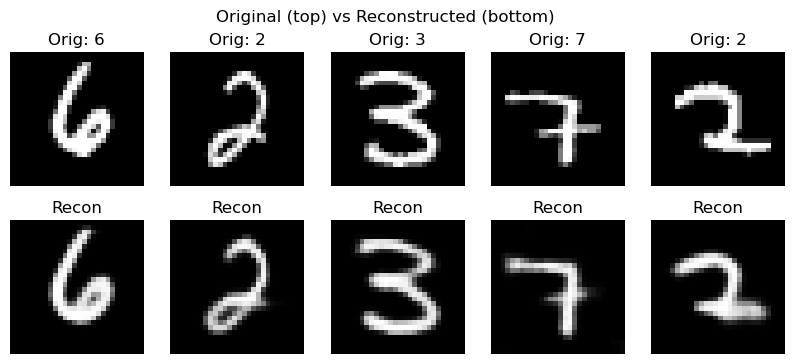

In [12]:
np.random.seed(random_seed)
indices = np.random.choice(len(test_dataset), size=5, replace=False)
sample_images = [test_dataset[i][0] for i in indices]
sample_labels = [test_dataset[i][1] for i in indices]

with torch.no_grad():
    batch = torch.stack(sample_images).to(device)
    reconstructed, _, _ = model(batch)

    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Original image
        plt.subplot(2, 5, i + 1)
        plt.imshow(batch[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Orig: {sample_labels[i]}')
        plt.axis('off')
        # Reconstructed image
        plt.subplot(2, 5, i + 6)
        plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        plt.title('Recon')
        plt.axis('off')
    plt.suptitle('Original (top) vs Reconstructed (bottom)')
    plt.show()


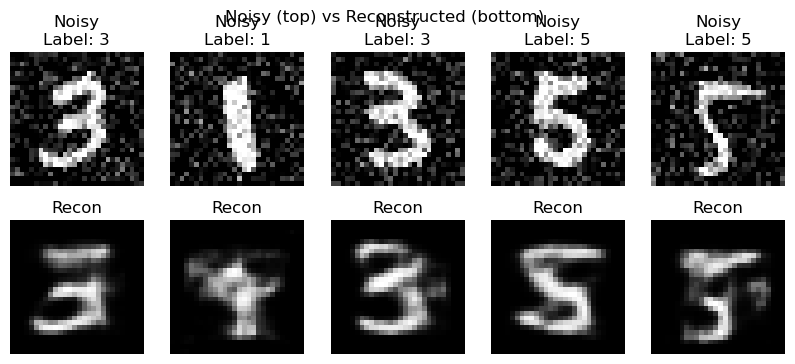

In [ ]:
# Noisy reconstruction.
# This wouldn't work as the VAE hasn't been trained to handle noise.
# Check the other notebook for a proper denoising VAE implementation.


indices = np.random.choice(len(test_dataset), size=5, replace=False)
sample_images = [test_dataset[i][0] for i in indices]
sample_labels = [test_dataset[i][1] for i in indices]

# Add Gaussian noise to each image
noisy_images = []
for img in sample_images:
    noise = torch.randn_like(img) * 0.2  # adjust stddev as needed
    noisy_img = img + noise
    noisy_img = torch.clamp(noisy_img, 0, 1)
    noisy_images.append(noisy_img)

with torch.no_grad():
    batch = torch.stack(noisy_images).to(device)
    reconstructed, _, _ = model(batch)

    plt.figure(figsize=(10, 4))
    for i in range(5):
        # Noisy image
        plt.subplot(2, 5, i + 1)
        plt.imshow(batch[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Noisy\nLabel: {sample_labels[i]}')
        plt.axis('off')
        # Reconstructed image
        plt.subplot(2, 5, i + 6)
        plt.imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
        plt.title('Recon')
        plt.axis('off')
    plt.suptitle('Noisy (top) vs Reconstructed (bottom)')
    plt.show()

torch.Size([1, 28, 28]) torch.Size([1, 28, 28])
torch.Size([2, 3136])


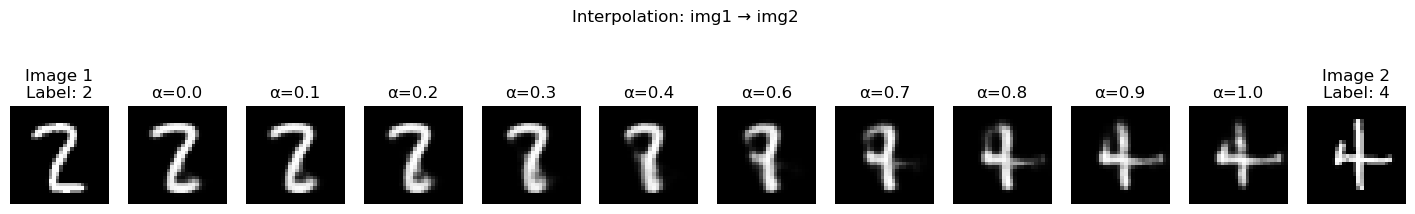

In [24]:
label1, label2 = 0, 0

while label1 == label2:
    indices = np.random.choice(len(test_dataset), size=2, replace=False)
    sample_images = [test_dataset[i][0] for i in indices]
    sample_labels = [test_dataset[i][1] for i in indices]
    img1, img2 = sample_images
    label1, label2 = sample_labels

print(img1.shape, img2.shape)

# Convert images to latent vectors z1,z2
z = model.get_latents(torch.stack([img1, img2]).to(device))
print(z.shape)
z1 = z[0].cpu()
z2 = z[1].cpu()

with torch.no_grad():
    alphas = np.linspace(0, 1, 10)
    interpolated_latents = [a * z2 + (1 - a) * z1 for a in alphas]
    with torch.no_grad():
        recons = model.unflatten(torch.stack(interpolated_latents).to(device))
        recons = model.decoder(recons)
        recons = recons.cpu()

    plt.figure(figsize=(18, 3))
    # Draw img1
    plt.subplot(1, len(alphas) + 2, 1)
    plt.imshow(img1.squeeze().cpu(), cmap='gray')
    plt.title(f'Image 1\nLabel: {label1}')
    plt.axis('off')

    # Draw reconstructions
    for i, (a, recon) in enumerate(zip(alphas, recons)):
        plt.subplot(1, len(alphas) + 2, i + 2)
        plt.imshow(recon.squeeze(), cmap='gray')
        plt.title(f'α={a:.1f}')
        plt.axis('off')

    # Draw img2
    plt.subplot(1, len(alphas) + 2, len(alphas) + 2)
    plt.imshow(img2.squeeze().cpu(), cmap='gray')
    plt.title(f'Image 2\nLabel: {label2}')
    plt.axis('off')

    plt.suptitle('Interpolation: img1 → img2')
    plt.show()

In [16]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(3, 3))
im = ax.imshow(img1.squeeze().cpu(), cmap='gray', animated=True)
ax.axis('off')

def animate(i):
    alpha = i / 59  # 60 frames for smoothness
    interpolated = (1 - alpha) * z1 + alpha * z2
    with torch.no_grad():
        recon = model.unflatten(interpolated.unsqueeze(0).to(device))
        recon = model.decoder(recon).cpu().squeeze()
    im.set_array(recon)
    ax.set_title(f'α={alpha:.2f}')
    return [im]

ani = FuncAnimation(fig, animate, frames=60, interval=50, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())